In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

FIG_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5"
TAB_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Figure dir:", FIG_DIR)
print("Table dir:", TAB_DIR)

Figure dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5
Table dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5


In [3]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import warnings
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_BENCHMARK_5Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_5y"
OUTPUTS_BENCHMARK_10Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_10y"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_BENCHMARK_5Y_DIR,
    OUTPUTS_BENCHMARK_10Y_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]
TRANSACTION_COST = 0.001

print("ASSETS:", ASSETS)
print("LOOKBACK:", LOOKBACK)
print("TRANSACTION_COST:", TRANSACTION_COST)

ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
LOOKBACK: 20
TRANSACTION_COST: 0.001


In [5]:
# ============================================================
# CELL 04 — Metric helper
# ============================================================

def compute_metrics_from_rollout(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = float(pv[-1] - 1.0)
    avg_daily_return = float(np.mean(ret))
    daily_volatility = float(np.std(ret))
    sharpe_approx = float(avg_daily_return / (daily_volatility + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))
    total_trading_cost = float(df_rollout["trading_cost"].sum())
    avg_trading_cost = float(df_rollout["trading_cost"].mean())

    return {
        "n_steps": int(len(df_rollout)),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": cumulative_return,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_volatility,
        "sharpe_approx": sharpe_approx,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "total_trading_cost": total_trading_cost,
        "avg_trading_cost": avg_trading_cost,
    }

In [6]:
# ============================================================
# CELL 05 — Buy-and-hold rollout function
# ============================================================

def run_buy_and_hold_rollout(
    y: np.ndarray,
    dates: np.ndarray,
    assets: list,
    transaction_cost: float = 0.001,
) -> pd.DataFrame:
    """
    y: shape [T, N], simple returns
    dates: shape [T]
    """
    y = y.astype(np.float32)
    n_steps, n_assets = y.shape

    # initial equal-weight allocation
    weights = np.ones(n_assets, dtype=np.float32) / n_assets
    prev_weights = np.ones(n_assets, dtype=np.float32) / n_assets
    portfolio_value = 1.0

    rows = []

    for t in range(n_steps):
        r_t = y[t]

        # rebalance only at first step from prev_weights -> weights
        turnover = float(np.sum(np.abs(weights - prev_weights))) if t == 0 else 0.0
        trading_cost = float(transaction_cost * turnover)

        portfolio_simple_return = float(np.dot(weights, r_t))
        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = float(np.log(1.0 + portfolio_simple_return))
        reward_cost_aware = float(reward_no_cost - trading_cost)

        gross_value_next = portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)
        portfolio_value = float(net_value_next)

        row = {
            "date": str(dates[t]),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": portfolio_value,
        }

        for i, asset in enumerate(assets):
            row[f"w_{asset}"] = float(weights[i])

        rows.append(row)

        # after market move, weights drift naturally
        asset_growth = weights * (1.0 + r_t)
        denom = float(np.sum(asset_growth))
        denom = max(denom, 1e-12)
        new_weights = asset_growth / denom

        prev_weights = weights.copy()
        weights = new_weights.astype(np.float32)

    return pd.DataFrame(rows)

In [7]:
# ============================================================
# CELL 06 — Load 5Y env-ready data
# ============================================================

env_ready_5y = np.load(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz", allow_pickle=True)

data_5y = {
    "train": {
        "y": env_ready_5y["y_train"].astype(np.float32),
        "dates": env_ready_5y["dates_train"],
    },
    "val": {
        "y": env_ready_5y["y_val"].astype(np.float32),
        "dates": env_ready_5y["dates_val"],
    },
    "test": {
        "y": env_ready_5y["y_test"].astype(np.float32),
        "dates": env_ready_5y["dates_test"],
    },
}

for split in ["train", "val", "test"]:
    print(split, data_5y[split]["y"].shape, data_5y[split]["dates"].shape)

train (717, 5) (717,)
val (250, 5) (250,)
test (251, 5) (251,)


In [8]:
# ============================================================
# CELL 07 — Run buy-and-hold on 5Y
# ============================================================

buyhold_rollouts_5y = {}
buyhold_rows_5y = []

for split in ["train", "val", "test"]:
    rollout_df = run_buy_and_hold_rollout(
        y=data_5y[split]["y"],
        dates=data_5y[split]["dates"],
        assets=ASSETS,
        transaction_cost=TRANSACTION_COST,
    )
    buyhold_rollouts_5y[split] = rollout_df

    metrics = compute_metrics_from_rollout(rollout_df)
    buyhold_rows_5y.append({
        "model": "BuyHold_EqualWeight",
        "split": split,
        **metrics,
    })

buyhold_metrics_5y = pd.DataFrame(buyhold_rows_5y)
buyhold_metrics_5y.to_csv(f"{TAB_DIR}/buyhold_5y.csv", index=False)
display(buyhold_metrics_5y)

,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,BuyHold_EqualWeight,train,717,1.341765,0.341765,0.000565,0.017593,0.509788,-0.281512,0.0,0.0,0.0
1,BuyHold_EqualWeight,val,250,1.390120,0.390120,0.001370,0.010120,2.148305,-0.102857,0.0,0.0,0.0
2,BuyHold_EqualWeight,test,251,1.249163,0.249163,0.000925,0.008739,1.680247,-0.096735,0.0,0.0,0.0


In [9]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=buyhold_metrics_5y)

https://docs.google.com/spreadsheets/d/1jg1Ruyh4Lh82p2MBH-W15gYFvrC_7EEqY1eS7V5DRmQ/edit#gid=0


In [10]:
# ============================================================
# CELL 08 — Save 5Y buy-and-hold outputs
# ============================================================

for split in ["train", "val", "test"]:
    buyhold_rollouts_5y[split].to_csv(
        f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_rollout_{split}_5y.csv",
        index=False
    )

buyhold_metrics_5y.to_csv(
    f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_metrics_5y.csv",
    index=False
)

print("Saved 5Y buy-and-hold outputs.")

Saved 5Y buy-and-hold outputs.


In [11]:
# ============================================================
# CELL 09 — Load 10Y tensor bundle and standardize with TRAIN only
# ============================================================

bundle_10y = np.load(f"{DATA_PROCESSED_DIR}/tensor_bundle_10y.npz", allow_pickle=True)

X_raw_10y = bundle_10y["X"].astype(np.float32)
y_10y = bundle_10y["y"].astype(np.float32)
dates_10y = pd.to_datetime(bundle_10y["dates"])
splits_10y = bundle_10y["splits"]

train_mask = (splits_10y == "train")
val_mask = (splits_10y == "val")
test_mask = (splits_10y == "test")

# standardization is not needed for buy-and-hold directly, but we keep split logic consistent
data_10y = {
    "train": {
        "y": y_10y[train_mask],
        "dates": np.array(dates_10y[train_mask].astype(str)),
    },
    "val": {
        "y": y_10y[val_mask],
        "dates": np.array(dates_10y[val_mask].astype(str)),
    },
    "test": {
        "y": y_10y[test_mask],
        "dates": np.array(dates_10y[test_mask].astype(str)),
    },
}

for split in ["train", "val", "test"]:
    print(split, data_10y[split]["y"].shape, data_10y[split]["dates"].shape)

train (1472, 5) (1472,)
val (503, 5) (503,)
test (501, 5) (501,)


In [12]:
# ============================================================
# CELL 10 — Run buy-and-hold on 10Y
# ============================================================

buyhold_rollouts_10y = {}
buyhold_rows_10y = []

for split in ["train", "val", "test"]:
    rollout_df = run_buy_and_hold_rollout(
        y=data_10y[split]["y"],
        dates=data_10y[split]["dates"],
        assets=ASSETS,
        transaction_cost=TRANSACTION_COST,
    )
    buyhold_rollouts_10y[split] = rollout_df

    metrics = compute_metrics_from_rollout(rollout_df)
    buyhold_rows_10y.append({
        "model": "BuyHold_EqualWeight",
        "split": split,
        **metrics,
    })

buyhold_metrics_10y = pd.DataFrame(buyhold_rows_10y)
display(buyhold_metrics_10y)

,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,BuyHold_EqualWeight,train,1472,4.157526,3.157526,0.001070,0.014236,1.193000,-0.260812,0.0,0.0,0.0
1,BuyHold_EqualWeight,val,503,0.963545,-0.036455,0.000015,0.013328,0.017971,-0.270693,0.0,0.0,0.0
2,BuyHold_EqualWeight,test,501,1.780724,0.780724,0.001201,0.009848,1.935857,-0.113614,0.0,0.0,0.0


In [13]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=buyhold_metrics_10y)

https://docs.google.com/spreadsheets/d/1Wi6GsM2uvWZe8xhg_d7haba4o0C8wiUxr0MmEvOvQfw/edit#gid=0


In [14]:
# ============================================================
# CELL 11 — Save 10Y buy-and-hold outputs
# ============================================================

for split in ["train", "val", "test"]:
    buyhold_rollouts_10y[split].to_csv(
        f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_rollout_{split}_10y.csv",
        index=False
    )

buyhold_metrics_10y.to_csv(
    f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_metrics_10y.csv",
    index=False
)

print("Saved 10Y buy-and-hold outputs.")

Saved 10Y buy-and-hold outputs.


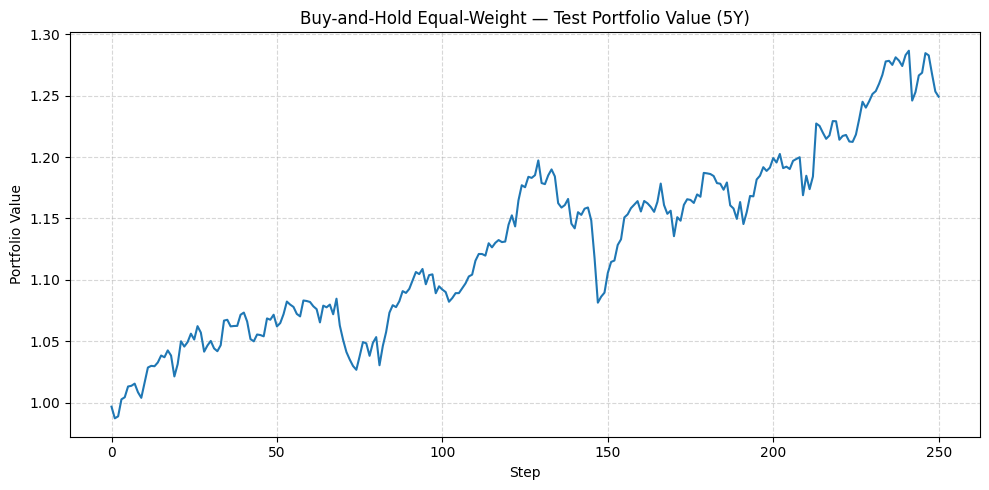

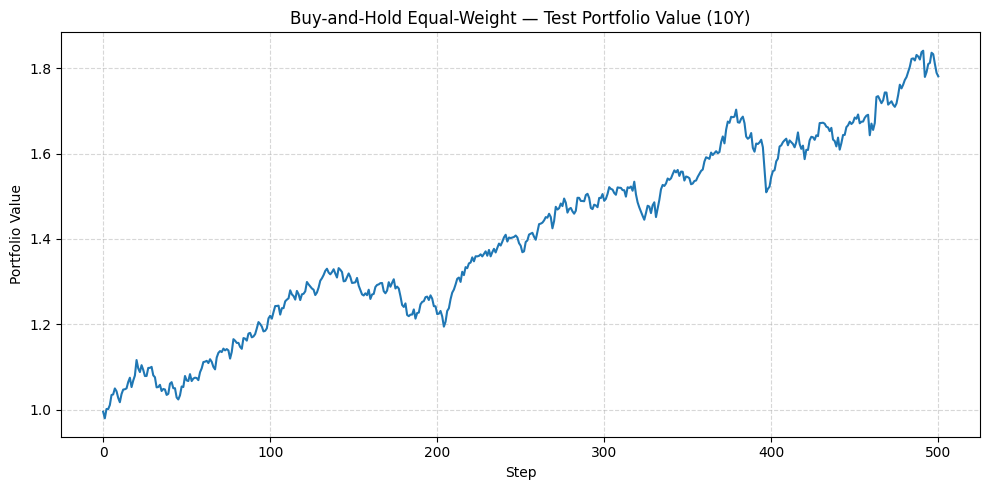

In [15]:
# ============================================================
# CELL 12 — Plot 5Y and 10Y test portfolio value curves
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(buyhold_rollouts_5y["test"]["portfolio_value"].values)
plt.title("Buy-and-Hold Equal-Weight — Test Portfolio Value (5Y)")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(buyhold_rollouts_10y["test"]["portfolio_value"].values)
plt.title("Buy-and-Hold Equal-Weight — Test Portfolio Value (10Y)")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/buyhold_5y_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# CELL 13 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_metrics_5y.csv",
    f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_metrics_10y.csv",
    f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_rollout_test_5y.csv",
    f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_rollout_test_10y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

print("All buy-and-hold benchmark notebook checks passed.")

All buy-and-hold benchmark notebook checks passed.
